# 5.0 Evaluación de los resultados

Este notebook evalúa los clusters creados en la fase de modelado. El análisis busca responder:

> **¿Qué caracteriza a los perfiles de resiliencia académica, es decir, estudiantes con bajo índice socioeconómico (INSE) que logran ubicarse en percentiles sobresalientes en Saber Pro?**

Como es aprendizaje no supervisado, no hay una respuesta correcta para calcular exactitud. Se revisan la separación, el tamaño y las características de los clusters, además de su relación con la resiliencia.

## 1. Librerías y carga de resultados

Se usa el CSV generado en `4.0-modeling.ipynb`. Ya contiene los clusters, la bandera de resiliencia y las componentes PCA, así que no hace falta cargar modelos guardados.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

if Path('data/processed/saber_pro_2024_clusters_estudiantes.csv').exists():
    project_root = Path.cwd()
else:
    project_root = Path.cwd().parent

results_path = project_root / 'data/processed/saber_pro_2024_clusters_estudiantes.csv'
df = pd.read_csv(results_path, encoding='utf-8-sig', low_memory=False)
print(f'Resultados cargados: {len(df):,} filas x {df.shape[1]} columnas')
display(df.head())

Resultados cargados: 246,792 filas x 66 columnas


,estu_consecutivo,cluster_kmeans,cluster_dbscan,resiliencia_flag,punt_global,percentil_global,estu_inse_individual,indice_bienes_hogar,fami_estratovivienda,fami_educacionmadre,...,pca_38,pca_39,pca_40,pca_41,pca_42,pca_43,pca_44,pca_45,pca_plot_1,pca_plot_2
0,EK202410108477,3,13.0,False,194,98.0,45.536022,4,Estrato 2,Técnica o tecnológica completa,...,1.615743,1.886163,-0.843709,-1.425202,-0.250222,0.716669,0.472001,0.311160,0.958665,1.250437
1,EK202410075644,0,NaN,False,176,89.0,44.102566,5,Estrato 2,Primaria completa,...,0.000573,0.253372,-0.244439,-0.380252,-0.068307,0.519056,0.424991,0.225821,1.048839,-0.304929
2,EK202410088553,12,NaN,False,149,56.0,59.191883,6,Estrato 3,Técnica o tecnológica completa,...,-0.027507,-0.476283,0.075532,-0.030046,-0.004058,0.039720,-0.293062,-0.643234,0.891618,2.344504
3,EK202410022739,0,NaN,False,149,55.0,63.126678,7,Estrato 4,Secundaria (Bachillerato) completa,...,0.187506,-0.153522,-0.036262,0.031899,-0.026094,-0.019215,0.123321,-0.174990,0.879490,3.085860
4,EK202410117700,13,NaN,False,150,56.0,57.556831,6,Estrato 3,Educación profesional completa,...,0.650708,1.073515,-0.780592,-0.381740,-0.057017,-0.161322,0.379741,0.003020,0.949780,2.331374


## 2. Verificación de los resultados

K-Means debe tener una asignación para todos los estudiantes. DBSCAN solo se entrenó con una muestra, por lo que es normal que su columna tenga valores vacíos.

In [11]:
required_columns = ['cluster_kmeans', 'cluster_dbscan', 'resiliencia_flag', 'punt_global',
                    'percentil_global', 'estu_inse_individual', 'indice_bienes_hogar',
                    'pca_plot_1', 'pca_plot_2']
missing_columns = [col for col in required_columns if col not in df.columns]
assert not missing_columns, f'Faltan columnas: {missing_columns}'
assert df['cluster_kmeans'].notna().all(), 'K-Means debe cubrir todos los registros'

pca_columns = [col for col in df.columns
               if col.startswith('pca_') and not col.startswith('pca_plot_')]
coverage = pd.DataFrame({
    'modelo': ['K-Means', 'DBSCAN'],
    'registros_evaluables': [df['cluster_kmeans'].notna().sum(),
                              df['cluster_dbscan'].notna().sum()]
})
coverage['porcentaje_del_total'] = coverage['registros_evaluables'] / len(df) * 100
print(f'Componentes PCA disponibles: {len(pca_columns)}')
display(coverage.round(2))

Componentes PCA disponibles: 45


,modelo,registros_evaluables,porcentaje_del_total
0,K-Means,246792,100.00
1,DBSCAN,15000,6.08


## 3. Evaluación de K-Means

Se calculan tres métricas internas. **Silhouette** va de -1 a 1 y es mejor cuando aumenta. **Davies-Bouldin** es mejor cuando disminuye. **Calinski-Harabasz** es mayor cuando hay más separación, aunque sirve principalmente para comparar modelos sobre los mismos datos. Silhouette usa una muestra de 10.000 registros para que el cálculo sea rápido.

,métrica,resultado
0,Silhouette,0.135
1,Davies-Bouldin,2.074
2,Calinski-Harabasz,11629.097


,cluster,estudiantes,porcentaje
0,0,11432,4.63
1,1,24247,9.82
2,2,6480,2.63
3,3,26678,10.81
4,4,78436,31.78
5,5,5409,2.19
6,6,11826,4.79
7,7,11380,4.61
8,8,5361,2.17
9,9,14490,5.87


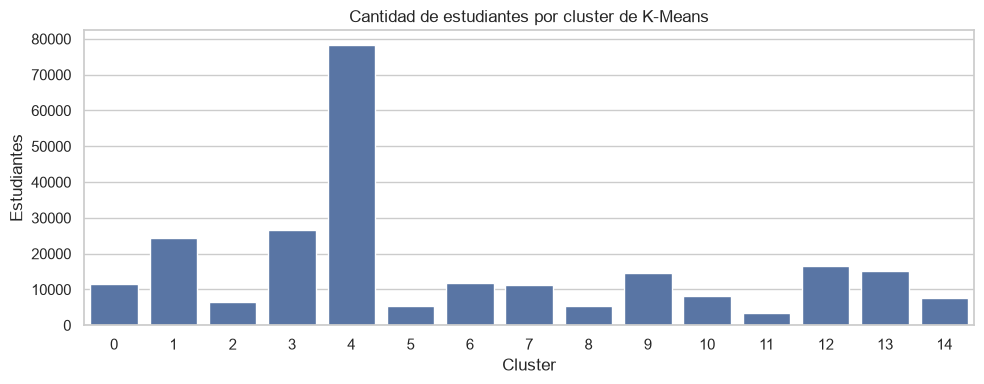

In [13]:
X_pca = df[pca_columns].to_numpy(dtype='float32')
kmeans_labels = df['cluster_kmeans'].to_numpy()
kmeans_metrics = pd.DataFrame({
    'métrica': ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'resultado': [
        silhouette_score(X_pca, kmeans_labels, sample_size=10_000,
                         random_state=RANDOM_STATE),
        davies_bouldin_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, kmeans_labels)
    ]
})
display(kmeans_metrics.round(3))

kmeans_sizes = df['cluster_kmeans'].value_counts().sort_index().rename_axis('cluster').reset_index(name='estudiantes')
kmeans_sizes['porcentaje'] = kmeans_sizes['estudiantes'] / len(df) * 100
display(kmeans_sizes.round(2))

plt.figure(figsize=(10, 4))
sns.barplot(data=kmeans_sizes, x='cluster', y='estudiantes', color='#4C72B0')
plt.title('Cantidad de estudiantes por cluster de K-Means')
plt.xlabel('Cluster')
plt.ylabel('Estudiantes')
plt.tight_layout()
plt.show()

El Silhouette cercano a **0,14** y el Davies-Bouldin cercano a **2,07** indican que varios clusters se superponen. Los tamaños tampoco son equilibrados: el cluster 4 contiene cerca del 32% de la población. Los grupos deben entenderse como perfiles exploratorios y no como categorías naturales completamente separadas.

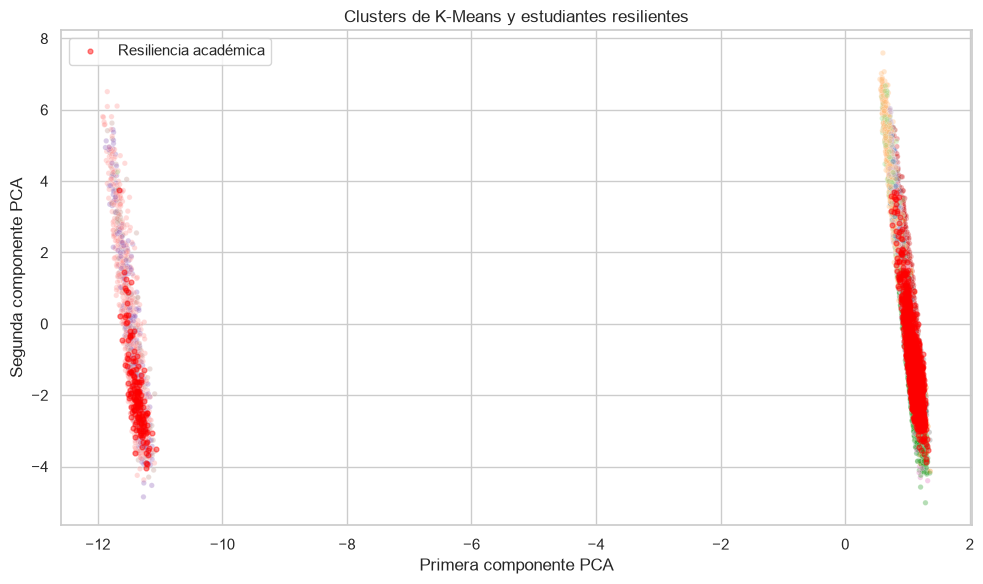

In [14]:
plot_sample = df.sample(n=min(15_000, len(df)), random_state=RANDOM_STATE)
resilient_students = df[df['resiliencia_flag']]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_sample, x='pca_plot_1', y='pca_plot_2',
                hue='cluster_kmeans', palette='tab20', s=15, alpha=0.35, legend=False)
plt.scatter(resilient_students['pca_plot_1'], resilient_students['pca_plot_2'],
            color='red', s=12, alpha=0.45, label='Resiliencia académica')
plt.title('Clusters de K-Means y estudiantes resilientes')
plt.xlabel('Primera componente PCA')
plt.ylabel('Segunda componente PCA')
plt.legend()
plt.tight_layout()
plt.show()

La proyección confirma que varios grupos se encuentran cerca. Los resilientes tampoco forman una región aislada, sino que aparecen en diferentes perfiles. Esta gráfica solo usa dos componentes para visualizar; el modelo utilizó 45.

## 4. Evaluación de DBSCAN

DBSCAN se aplicó a 15.000 estudiantes. La etiqueta `-1` representa ruido y los vacíos son registros que no estuvieron en la muestra. Las métricas excluyen el ruido.

In [15]:
dbscan_sample = df[df['cluster_dbscan'].notna()].copy()
dbscan_grouped = dbscan_sample[dbscan_sample['cluster_dbscan'] != -1].copy()
dbscan_clusters = dbscan_grouped['cluster_dbscan'].nunique()
dbscan_noise = (dbscan_sample['cluster_dbscan'] == -1).sum()
dbscan_noise_pct = dbscan_noise / len(dbscan_sample) * 100
print(f'Registros de la muestra: {len(dbscan_sample):,}')
print(f'Clusters encontrados: {dbscan_clusters}')
print(f'Ruido: {dbscan_noise:,} ({dbscan_noise_pct:.2f}%)')

X_dbscan = dbscan_grouped[pca_columns].to_numpy(dtype='float32')
dbscan_labels = dbscan_grouped['cluster_dbscan'].astype(int).to_numpy()
dbscan_metrics = pd.DataFrame({
    'métrica': ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'resultado': [
        silhouette_score(X_dbscan, dbscan_labels, sample_size=min(10_000, len(X_dbscan)),
                         random_state=RANDOM_STATE),
        davies_bouldin_score(X_dbscan, dbscan_labels),
        calinski_harabasz_score(X_dbscan, dbscan_labels)
    ]
})
display(dbscan_metrics.round(3))

dbscan_sizes = dbscan_sample['cluster_dbscan'].value_counts().sort_index().rename_axis('cluster').reset_index(name='estudiantes')
display(dbscan_sizes)
display(pd.crosstab(dbscan_sample['cluster_dbscan'], dbscan_sample['resiliencia_flag']))

Registros de la muestra: 15,000
Clusters encontrados: 20
Ruido: 472 (3.15%)


,métrica,resultado
0,Silhouette,0.270
1,Davies-Bouldin,0.849
2,Calinski-Harabasz,241.813


,cluster,estudiantes
0,-1.0,472
1,0.0,13064
2,1.0,769
3,2.0,114
4,3.0,74
5,4.0,17
6,5.0,51
7,6.0,72
8,7.0,63
9,8.0,59


resiliencia_flag,False,True
cluster_dbscan,,
-1.0,469,3
0.0,12954,110
1.0,759,10
2.0,114,0
3.0,74,0
4.0,17,0
5.0,51,0
6.0,72,0
7.0,63,0


DBSCAN obtiene un Silhouette cercano a **0,27** y marca aproximadamente el **3,15%** como ruido. Sin embargo, su cluster 0 concentra alrededor del 87% de la muestra y los demás son muy pequeños. Solo 3 resilientes aparecen como ruido. Por lo tanto, esta configuración no identifica la resiliencia como una anomalía clara. No se compara directamente con K-Means porque DBSCAN utilizó una muestra y sus métricas excluyen el ruido.

## 5. Perfil general de K-Means

,estudiantes,puntaje_promedio,percentil_promedio,inse_promedio,bienes_promedio,estudiantes_resilientes,porcentaje_resiliente
cluster_kmeans,,,,,,,
0,11432,150.02,54.71,52.30,4.71,72,0.63
1,24247,143.73,47.37,46.89,4.28,262,1.08
2,6480,138.10,40.55,43.86,3.85,67,1.03
3,26678,159.04,64.48,61.52,5.36,36,0.13
4,78436,141.25,44.52,44.33,4.01,1103,1.41
5,5409,153.84,58.33,60.06,5.54,9,0.17
6,11826,149.02,53.18,54.21,5.03,27,0.23
7,11380,150.29,54.45,50.88,4.49,114,1.00
8,5361,143.90,47.42,50.67,4.46,29,0.54


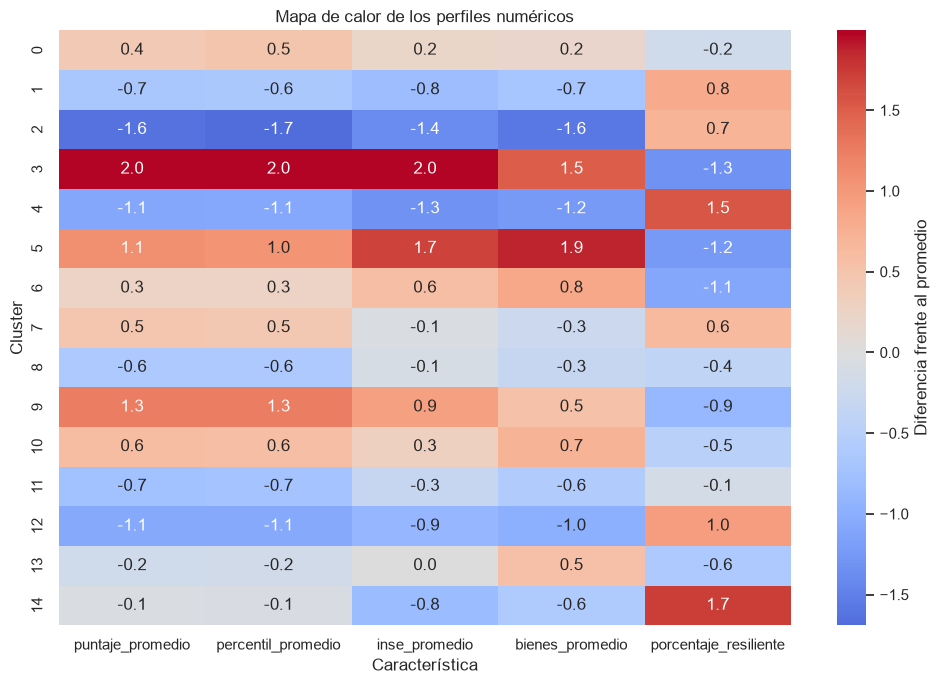

In [16]:
cluster_profile = df.groupby('cluster_kmeans').agg(
    estudiantes=('cluster_kmeans', 'size'),
    puntaje_promedio=('punt_global', 'mean'),
    percentil_promedio=('percentil_global', 'mean'),
    inse_promedio=('estu_inse_individual', 'mean'),
    bienes_promedio=('indice_bienes_hogar', 'mean'),
    estudiantes_resilientes=('resiliencia_flag', 'sum'),
    porcentaje_resiliente=('resiliencia_flag', 'mean')
)
cluster_profile['porcentaje_resiliente'] *= 100
display(cluster_profile.round(2))

heatmap_columns = ['puntaje_promedio', 'percentil_promedio', 'inse_promedio',
                   'bienes_promedio', 'porcentaje_resiliente']
heatmap_data = cluster_profile[heatmap_columns]
heatmap_scaled = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()
plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_scaled, cmap='coolwarm', center=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Diferencia frente al promedio'})
plt.title('Mapa de calor de los perfiles numéricos')
plt.xlabel('Característica')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

Los colores del mapa están estandarizados y solo sirven para comparar. Los clusters 3, 5 y 9 tienen desempeño e INSE relativamente altos. Los clusters 2, 4 y 12 tienen promedios menores. La resiliencia debe estudiarse solamente dentro de la población de bajo INSE para evitar que la composición de cada cluster distorsione la comparación.

## 6. Evaluación desde la pregunta de negocio

Bajo INSE se define como pertenecer al 25% inferior. Un estudiante resiliente pertenece a ese grupo y alcanza un percentil global mayor o igual a 90. Para hacer una comparación justa, se contrasta con estudiantes que también tienen bajo INSE pero no alcanzaron ese percentil.

In [17]:
inse_q25 = df['estu_inse_individual'].quantile(0.25)
low_inse = df[df['estu_inse_individual'] <= inse_q25].copy()
low_inse['grupo_resiliencia'] = np.where(low_inse['resiliencia_flag'],
                                          'Resiliente',
                                          'Bajo INSE no sobresaliente')
resilient_count = int(df['resiliencia_flag'].sum())
print(f'Umbral de bajo INSE: {inse_q25:.2f}')
print(f'Estudiantes con bajo INSE: {len(low_inse):,}')
print(f'Estudiantes resilientes: {resilient_count:,}')
print(f'Resilientes sobre el total: {resilient_count / len(df) * 100:.2f}%')
print(f'Resilientes entre estudiantes de bajo INSE: {resilient_count / len(low_inse) * 100:.2f}%')

numeric_comparison = low_inse.groupby('grupo_resiliencia')[
    ['punt_global', 'percentil_global', 'estu_inse_individual', 'indice_bienes_hogar']
].agg(['mean', 'median'])
display(numeric_comparison.round(2))

Umbral de bajo INSE: 42.81
Estudiantes con bajo INSE: 61,698
Estudiantes resilientes: 2,197
Resilientes sobre el total: 0.89%
Resilientes entre estudiantes de bajo INSE: 3.56%


punt_global        percentil_global         \
                                  mean median             mean median   
grupo_resiliencia                                                       
Bajo INSE no sobresaliente      135.47  136.0            37.83   35.0   
Resiliente                      186.87  184.0            94.04   94.0   

                           estu_inse_individual        indice_bienes_hogar  \
                                           mean median                mean   
grupo_resiliencia                                                            
Bajo INSE no sobresaliente                37.72  38.66                2.92   
Resiliente                                38.72  39.60                2.97   

                                   
                           median  
grupo_resiliencia                  
Bajo INSE no sobresaliente    3.0  
Resiliente                    3.0

Se identifican **2.197 resilientes**: 0,89% del total y 3,56% de quienes tienen bajo INSE. Su puntaje promedio es cercano a 187 y su percentil promedio es 94. Ambos grupos de bajo INSE tienen una mediana cercana a 3 bienes, así que la cantidad de bienes observados no muestra una diferencia importante. La diferencia en puntaje forma parte de la definición y no debe interpretarse como causa.

,estudiantes_bajo_inse,resilientes,tasa_resiliencia,participacion_en_resilientes
cluster_kmeans,,,,
0,1142,72,6.30,3.28
3,580,36,6.21,1.64
14,1957,113,5.77,5.14
9,871,47,5.40,2.14
10,892,41,4.60,1.87
7,2775,114,4.11,5.19
13,1631,66,4.05,3.00
1,7053,262,3.71,11.93
5,253,9,3.56,0.41


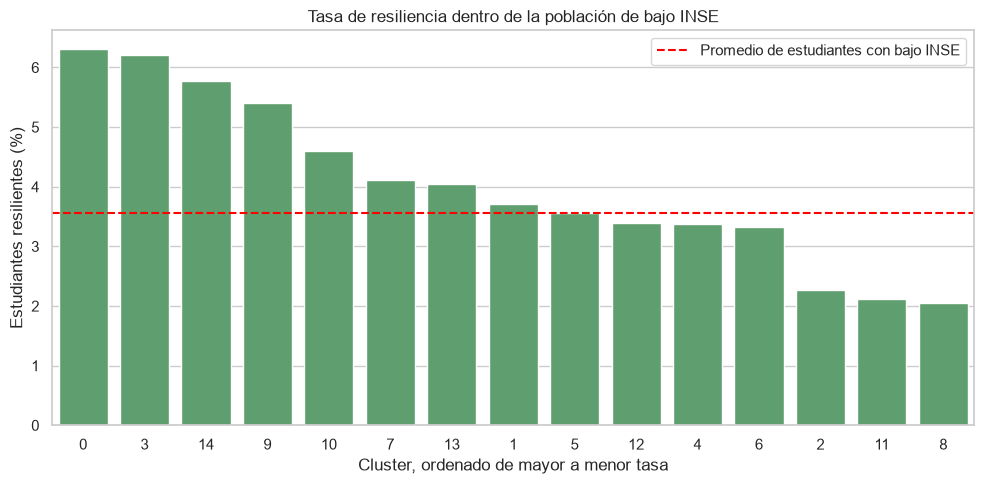

In [18]:
resilience_by_cluster = low_inse.groupby('cluster_kmeans').agg(
    estudiantes_bajo_inse=('cluster_kmeans', 'size'),
    resilientes=('resiliencia_flag', 'sum'),
    tasa_resiliencia=('resiliencia_flag', 'mean')
)
resilience_by_cluster['tasa_resiliencia'] *= 100
resilience_by_cluster['participacion_en_resilientes'] = (
    resilience_by_cluster['resilientes'] / resilient_count * 100
)
resilience_by_cluster = resilience_by_cluster.sort_values('tasa_resiliencia', ascending=False)
display(resilience_by_cluster.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(data=resilience_by_cluster.reset_index(), x='cluster_kmeans',
            y='tasa_resiliencia', order=resilience_by_cluster.index, color='#55A868')
plt.axhline(low_inse['resiliencia_flag'].mean() * 100, color='red', linestyle='--',
            label='Promedio de estudiantes con bajo INSE')
plt.title('Tasa de resiliencia dentro de la población de bajo INSE')
plt.xlabel('Cluster, ordenado de mayor a menor tasa')
plt.ylabel('Estudiantes resilientes (%)')
plt.legend()
plt.tight_layout()
plt.show()

Los clusters **0, 3 y 14** presentan las tasas más altas dentro de su población de bajo INSE: aproximadamente **6,30%, 6,21% y 5,77%**. El cluster 4 reúne cerca del **50% de todos los resilientes**, pero su tasa es 3,37%, ligeramente inferior al promedio de 3,56%. Contiene muchos casos principalmente porque es el cluster más grande.

### 6.1 Características familiares, educativas y territoriales

Las siguientes tablas muestran el porcentaje de cada categoría dentro de los dos grupos. Una diferencia positiva significa que la categoría aparece con mayor frecuencia entre los resilientes.

In [19]:
def compare_category(column, top=8):
    table = pd.crosstab(low_inse[column], low_inse['grupo_resiliencia'],
                        normalize='columns') * 100
    table['diferencia_pp'] = table['Resiliente'] - table['Bajo INSE no sobresaliente']
    return table.sort_values('diferencia_pp', ascending=False).head(top).round(2)

for column in ['fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre']:
    print(f'Comparación para: {column}')
    display(compare_category(column))

for column in ['estu_metodo_prgm', 'inst_caracter_academico', 'inst_origen']:
    print(f'Comparación para: {column}')
    display(compare_category(column))

Comparación para: fami_estratovivienda


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
fami_estratovivienda,,,
Estrato 2,36.04,42.28,6.25
Estrato 3,6.84,9.60,2.76
Estrato 4,0.48,1.27,0.80
Estrato 5,0.11,0.23,0.12
Estrato 6,0.05,0.14,0.08
Estrato 1,56.48,46.47,-10.01


Comparación para: fami_educacionmadre


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
fami_educacionmadre,,,
Secundaria (Bachillerato) completa,22.61,29.81,7.20
Secundaria (Bachillerato) incompleta,12.71,15.84,3.13
Técnica o tecnológica completa,6.74,9.29,2.55
Educación profesional completa,2.43,4.96,2.53
Educación profesional incompleta,0.60,1.59,0.99
No sabe,0.43,0.96,0.52
Postgrado,0.41,0.77,0.36
Técnica o tecnológica incompleta,2.20,2.14,-0.06


Comparación para: fami_educacionpadre


...

grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
estu_metodo_prgm,,,
PRESENCIAL,64.88,93.95,29.07
SEMI-PRESENCIAL,0.01,0.00,-0.01
DISTANCIA VITUAL,13.07,3.00,-10.06
DISTANCIA,22.05,3.05,-19.00


Comparación para: inst_caracter_academico


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
inst_caracter_academico,,,
UNIVERSIDAD,57.24,89.94,32.70
TÉCNICA PROFESIONAL,3.25,0.36,-2.89
INSTITUCIÓN TECNOLÓGICA,5.16,0.59,-4.57
INSTITUCIÓN UNIVERSITARIA,34.35,9.10,-25.25


Comparación para: inst_origen


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
inst_origen,,,
OFICIAL DEPARTAMENTAL,26.10,37.05,10.95
OFICIAL NACIONAL,28.24,31.09,2.85
OFICIAL MUNICIPAL,3.10,4.46,1.36
REGIMEN ESPECIAL,0.04,0.00,-0.04
NO OFICIAL - FUNDACIÓN,19.94,13.97,-5.96
NO OFICIAL - CORPORACIÓN,22.58,13.43,-9.15


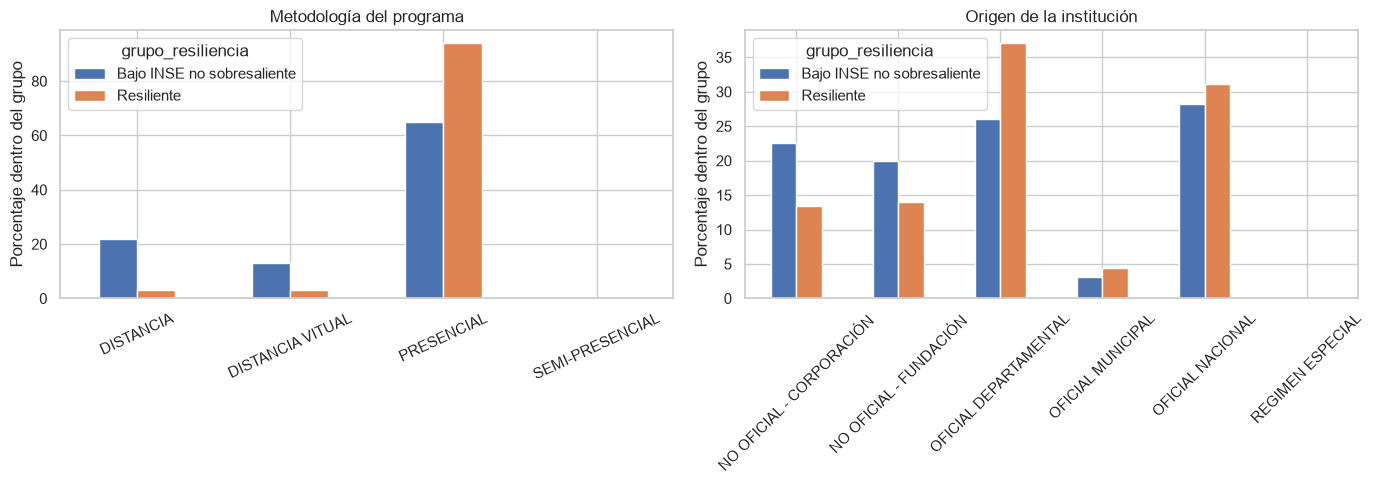

Departamentos con mayor diferencia a favor del grupo resiliente


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
estu_prgm_departamento,,,
ANTIOQUIA,7.55,11.70,4.15
SANTANDER,3.20,6.92,3.72
VALLE,5.31,8.42,3.11
BOYACA,2.64,4.69,2.05
ATLANTICO,5.66,7.60,1.94
CALDAS,0.92,2.82,1.90
CAUCA,2.93,4.46,1.53
META,0.98,1.73,0.75
MAGDALENA,2.15,2.78,0.62


Núcleos de pregrado con mayor diferencia a favor del grupo resiliente


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
estu_nucleo_pregrado,,,
INGENIERÍA CIVIL Y AFINES,2.13,7.19,5.06
MEDICINA,0.88,5.42,4.53
DERECHO Y AFINES,4.56,7.92,3.36
"INGENIERÍA ELECTRÓNICA, TELECOMUNICACIONES Y AFINES",1.09,3.14,2.05
INGENIERÍA MECÁNICA Y AFINES,0.96,3.00,2.04
"INGENIERÍA DE SISTEMAS, TELEMÁTICA Y AFINES",3.75,5.10,1.35
ECONOMÍA,1.37,2.64,1.27
"LENGUAS MODERNAS, LITERATURA, LINGÜÍSTICA Y AFINES",0.09,1.32,1.23
"BIOLOGÍA, MICROBIOLOGÍA Y AFINES",0.87,2.09,1.23


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
method_table = pd.crosstab(low_inse['estu_metodo_prgm'], low_inse['grupo_resiliencia'],
                           normalize='columns') * 100
method_table.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Metodología del programa')
axes[0].set_xlabel('')
axes[0].set_ylabel('Porcentaje dentro del grupo')
axes[0].tick_params(axis='x', rotation=25)

origin_table = pd.crosstab(low_inse['inst_origen'], low_inse['grupo_resiliencia'],
                           normalize='columns') * 100
origin_table.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Origen de la institución')
axes[1].set_xlabel('')
axes[1].set_ylabel('Porcentaje dentro del grupo')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Departamentos con mayor diferencia a favor del grupo resiliente')
display(compare_category('estu_prgm_departamento', top=10))
print('Núcleos de pregrado con mayor diferencia a favor del grupo resiliente')
display(compare_category('estu_nucleo_pregrado', top=10))

Entre los resilientes hay más estudiantes en modalidad presencial, universidades e instituciones oficiales. También hay mayor participación de padres con bachillerato completo o educación superior. Antioquia, Santander, Valle, Boyacá y Atlántico aparecen proporcionalmente más, al igual que Ingeniería Civil, Medicina, Derecho e Ingeniería Electrónica. Son asociaciones descriptivas: no prueban que estas características causen resiliencia.

## 7. Conclusiones finales

1. **La resiliencia es poco frecuente:** representa el 0,89% del conjunto y el 3,56% de la población con bajo INSE.
2. **No existe un único cluster resiliente:** los casos aparecen en los 15 clusters. Los clusters 0, 3 y 14 tienen las tasas más altas dentro del bajo INSE; el cluster 4 tiene la mayor cantidad por su tamaño.
3. **Los bienes del hogar no muestran una diferencia importante** entre los dos grupos de bajo INSE.
4. **El contexto educativo sí muestra diferencias:** modalidad presencial, universidades, instituciones oficiales y mayor educación familiar aparecen con más frecuencia entre resilientes.
5. **K-Means es útil como segmentación exploratoria**, pero su baja separación obliga a evitar categorías rígidas.
6. **DBSCAN no identificó la resiliencia como anomalía:** solo 3 resilientes de su muestra fueron ruido y la mayoría quedó en un cluster dominante.
7. **No se pueden afirmar causas:** los resultados describen asociaciones y perfiles, no efectos causales.

## 8. Decisión sobre los modelos

K-Means es el resultado más útil para comunicar perfiles porque cubre a todos los estudiantes. Debe presentarse junto con sus métricas y la advertencia de superposición. DBSCAN queda como análisis complementario sobre una muestra.

No fue necesario exportar modelos para esta evaluación: las etiquetas y componentes PCA fueron suficientes. Guardar el preprocesamiento, PCA y K-Means será necesario únicamente si en otra fase se desea asignar clusters a registros nuevos.